État initial: (0, 0)
Nouveau état: (0, 1) Récompense: -1 Terminé: False


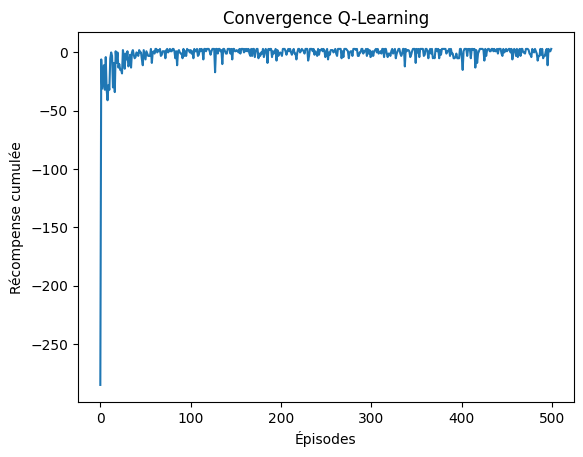

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from environment.warehouse_env import WarehouseEnv
import numpy as np 
import matplotlib.pyplot as plt 

# Créer l'environnement
env = WarehouseEnv(grid_size=(5, 5))

# Exemple d'utilisation
state = env.reset()
print("État initial:", state)

new_state, reward, done = env.step(3)  # action = droite
print("Nouveau état:", new_state, "Récompense:", reward, "Terminé:", done)

env.render()

# Hyperparamètres
episodes = 500
alpha = 0.1       # taux d'apprentissage
gamma = 0.9       # facteur de discount
epsilon = 0.2     # probabilité d'exploration

# Initialisation
env = WarehouseEnv(grid_size=(5, 5))
q_table = np.zeros((env.grid_size[0], env.grid_size[1], len(env.action_space)))

def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice(env.action_space)  # exploration
    else:
        x, y = state
        return np.argmax(q_table[x, y])            # exploitation

rewards_per_episode = []

# Boucle d'entraînement
for ep in range(episodes):
    state = env.reset()
    total_reward = 0

    while True:
        action = choose_action(state, epsilon)
        new_state, reward, done = env.step(action)

        # Mise à jour Q-Learning
        x, y = state
        nx, ny = new_state
        q_table[x, y, action] += alpha * (reward + gamma * np.max(q_table[nx, ny]) - q_table[x, y, action])

        state = new_state
        total_reward += reward

        if done:
            break

    rewards_per_episode.append(total_reward)

# Visualisation
plt.plot(rewards_per_episode)
plt.xlabel("Épisodes")
plt.ylabel("Récompense cumulée")
plt.title("Convergence Q-Learning")
plt.show()

In [3]:
import imageio
import os

# Créer le dossier demo si nécessaire
os.makedirs("demo", exist_ok=True)

frames = []
state = env.reset()
done = False

while not done:
    # Politique exploitante (pas d'exploration)
    action = np.argmax(q_table[state[0], state[1]])
    new_state, reward, done = env.step(action)

    frame = env.render()   # retourne une image numpy
    frames.append(frame)

    state = new_state

# Sauvegarde en vidéo avec FFMPEG
imageio.mimsave("demo/demo_qlearning.mp4", frames, fps=2, codec="libx264")
print("Vidéo sauvegardée dans demo/demo_qlearning.mp4")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (500, 500) to (512, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Vidéo sauvegardée dans demo/demo_qlearning.mp4
